In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 47.8±35.8 MB/s, size: 324.7 KB)
val: Scanning /kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible/test/labels... 2406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2406/2406 277.9it/s 8.7s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/angeltamang/velmet-violation-remove-redundant/helmet-dataset-yolo-compatible/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P  

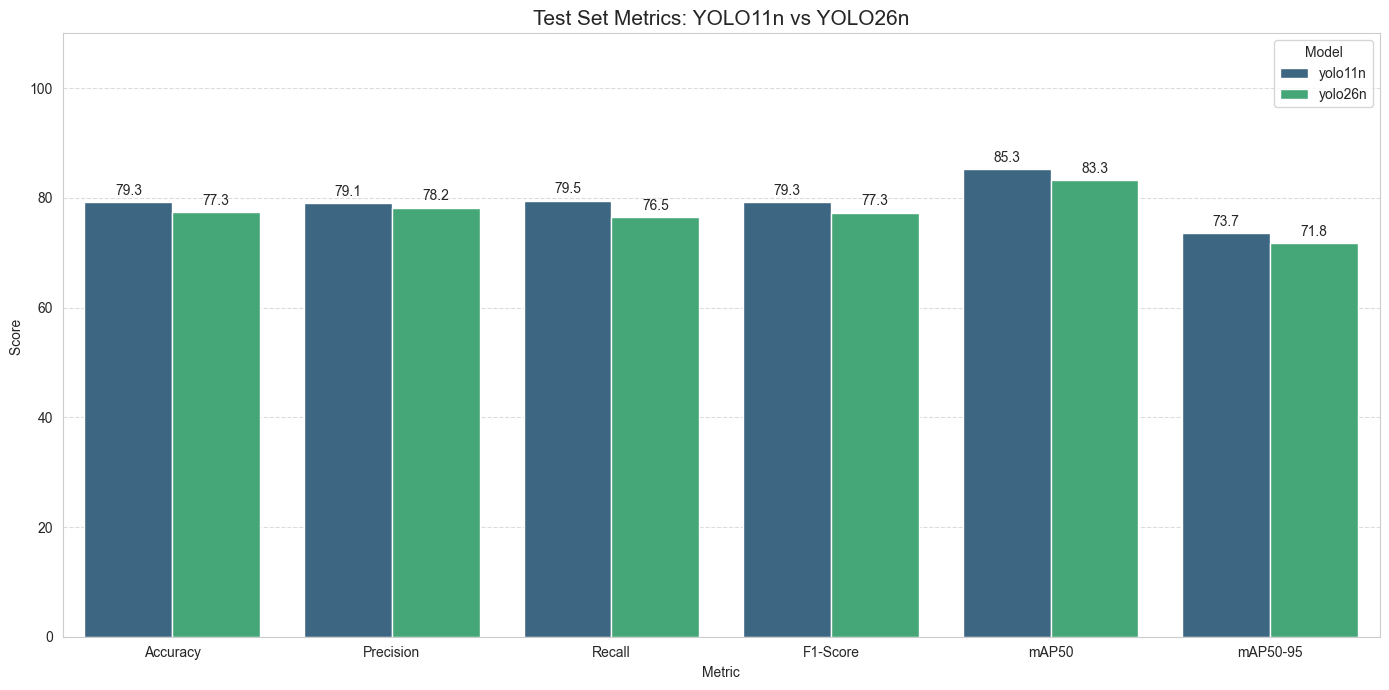

     Model  Accuracy  Precision  Recall  F1-Score  mAP50  mAP50-95
0  yolo11n     79.30      79.07   79.52     79.29  85.28     73.66
1  yolo26n     77.34      78.22   76.46     77.33  83.31     71.77


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO

BASE_PATH = "/kaggle/input/notebooks/angeltamang/baselines/runs/detect/Helmet_Detection_Comparison"
DATA_YAML = "/kaggle/input/notebooks/angeltamang/baselines/data_fixed.yaml"
OUTPUT_DIR = "/kaggle/working/evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_list = []

for m_name in ["yolo11n", "yolo26n"]:
    weights_path = f"{BASE_PATH}/{m_name}/weights/best.pt"
    
    if os.path.exists(weights_path):
        model = YOLO(weights_path)
        
        # Inference on test set
        results = model.val(
            data=DATA_YAML,
            split='test',
            plots=True,
            project=OUTPUT_DIR, 
            name=m_name
        )
        
        p = results.results_dict['metrics/precision(B)']
        r = results.results_dict['metrics/recall(B)']
        map50 = results.results_dict['metrics/mAP50(B)']
        map95 = results.results_dict['metrics/mAP50-95(B)']
        
        # Store metrics scaled to 0-100
        metrics_list.append({
            'Model': m_name,
            'Accuracy': ((p + r) / 2) * 100,
            'Precision': p * 100,
            'Recall': r * 100,
            'F1-Score': (2 * p * r / (p + r)) * 100 if (p + r) > 0 else 0,
            'mAP50': map50 * 100,
            'mAP50-95': map95 * 100            
        })

# Comparison df
comparison_df = pd.DataFrame(metrics_list)
plot_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.title('Test Set Metrics: YOLO11n vs YOLO26n', fontsize=15)
plt.ylabel('Score ')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/test_comparison_metrics.png")
plt.show()

print(comparison_df.round(2))

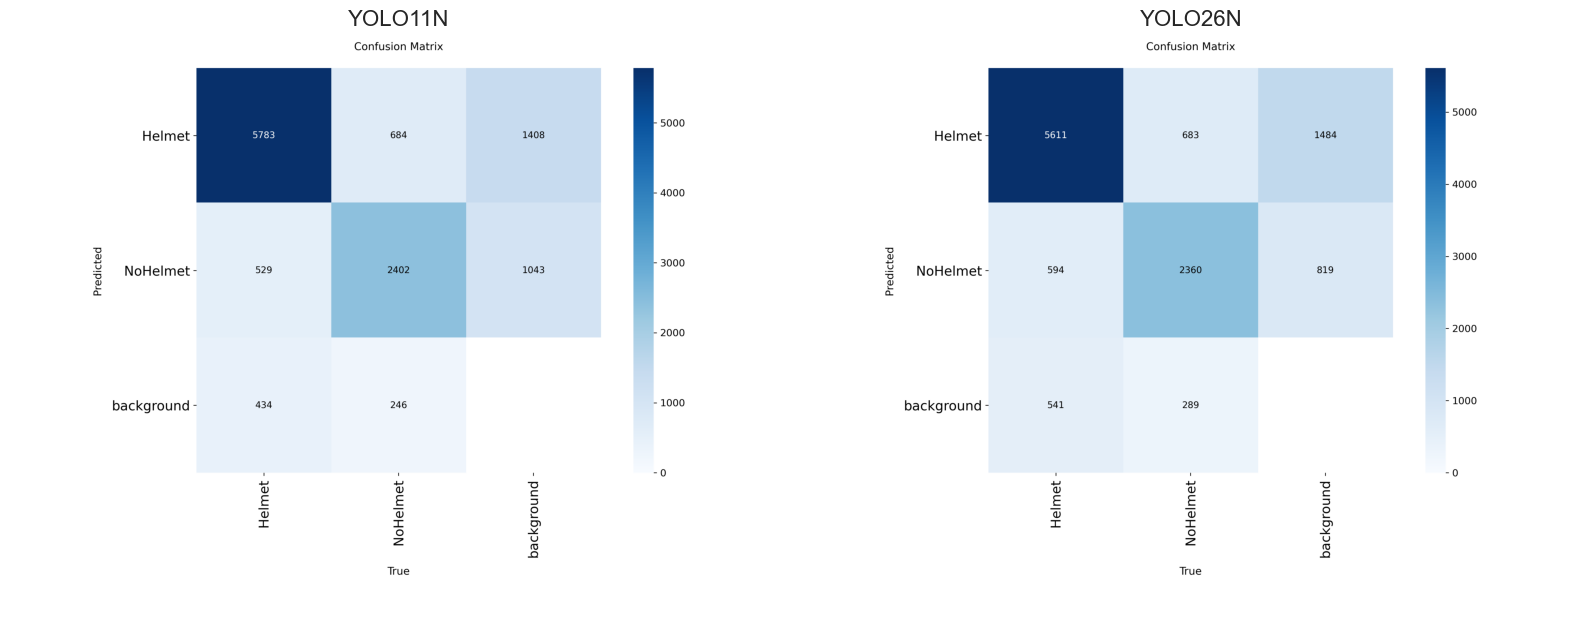

In [3]:
import matplotlib.image as mpimg

models = ["yolo11n", "yolo26n"]

# Confusion Matrix made by ultralytics
fig, axes = plt.subplots(1, 2, figsize=(16, 20))

for i, m_name in enumerate(models):
    img_path = os.path.join(OUTPUT_DIR, m_name, "confusion_matrix.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"File not found:\n{m_name}", 
                     ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Confusion_Matrix_comparison.png")
plt.show()

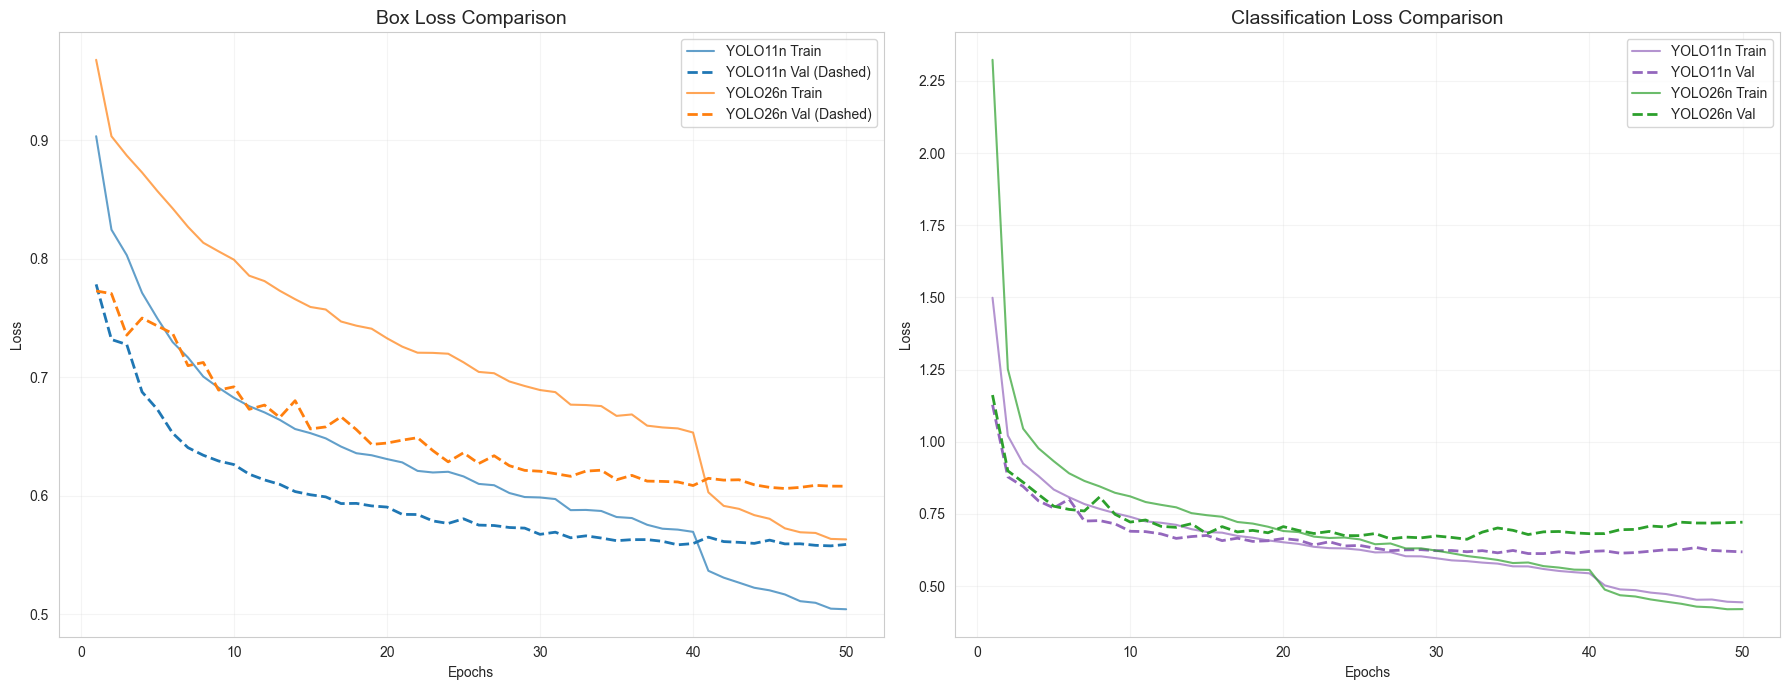

In [4]:
# Losses plots
CSV_11 = f"{BASE_PATH}/yolo11n/results.csv"
CSV_26 = f"{BASE_PATH}/yolo26n/results.csv"

df11 = pd.read_csv(CSV_11)
df11.columns = df11.columns.str.strip()

df26 = pd.read_csv(CSV_26)
df26.columns = df26.columns.str.strip()

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Box Loss 
# YOLO11n curves
ax[0].plot(df11['epoch'], df11['train/box_loss'], label='YOLO11n Train', color='#1f77b4', alpha=0.7)
ax[0].plot(df11['epoch'], df11['val/box_loss'], label='YOLO11n Val (Dashed)', color='#1f77b4', linestyle='--', linewidth=2)
# YOLO26n curves
ax[0].plot(df26['epoch'], df26['train/box_loss'], label='YOLO26n Train', color='#ff7f0e', alpha=0.7)
ax[0].plot(df26['epoch'], df26['val/box_loss'], label='YOLO26n Val (Dashed)', color='#ff7f0e', linestyle='--', linewidth=2)

ax[0].set_title('Box Loss Comparison', fontsize=14)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True, alpha=0.2)

# Classification Loss
# YOLO11n curves
ax[1].plot(df11['epoch'], df11['train/cls_loss'], label='YOLO11n Train', color='#9467bd', alpha=0.7)
ax[1].plot(df11['epoch'], df11['val/cls_loss'], label='YOLO11n Val', color='#9467bd', linestyle='--', linewidth=2)
# YOLO26n curves
ax[1].plot(df26['epoch'], df26['train/cls_loss'], label='YOLO26n Train', color='#2ca02c', alpha=0.7)
ax[1].plot(df26['epoch'], df26['val/cls_loss'], label='YOLO26n Val', color='#2ca02c', linestyle='--', linewidth=2)

ax[1].set_title('Classification Loss Comparison', fontsize=14)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_head_to_head_loss.png")
plt.show()

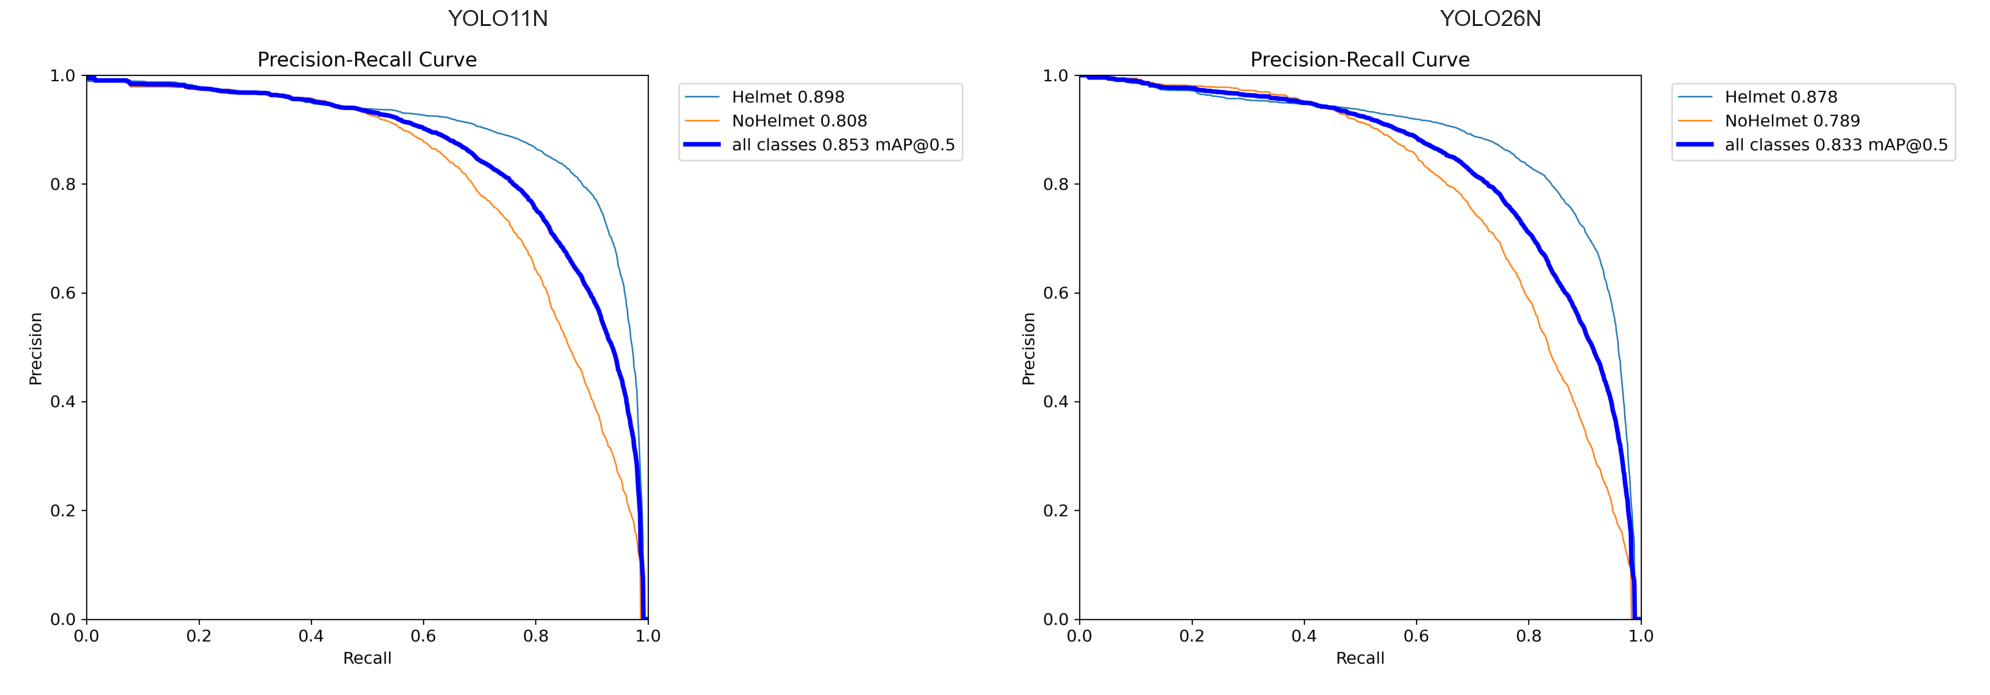

In [5]:
# PR Curves
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, m_name in enumerate(models):
    img_path = os.path.join(OUTPUT_DIR, m_name, "BoxPR_curve.png")
    
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
        axes[i].axis('off') 
    else:
        axes[i].text(0.5, 0.5, f"PR Curve not found for:\n{m_name}", 
                     ha='center', va='center', fontsize=12)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/PR_curve_comparison.png")
plt.show()

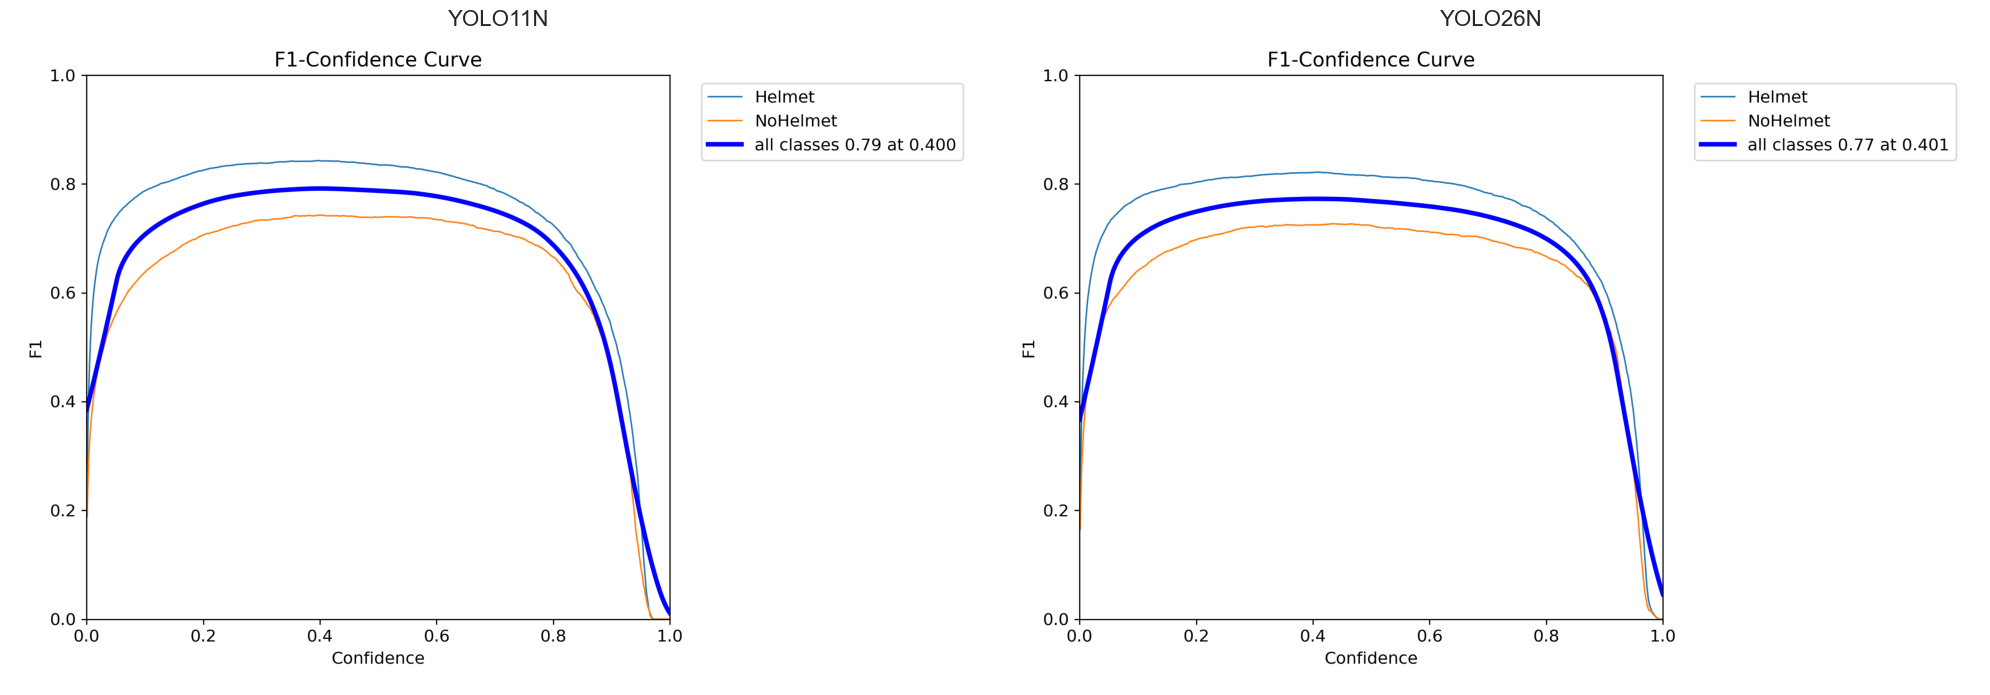

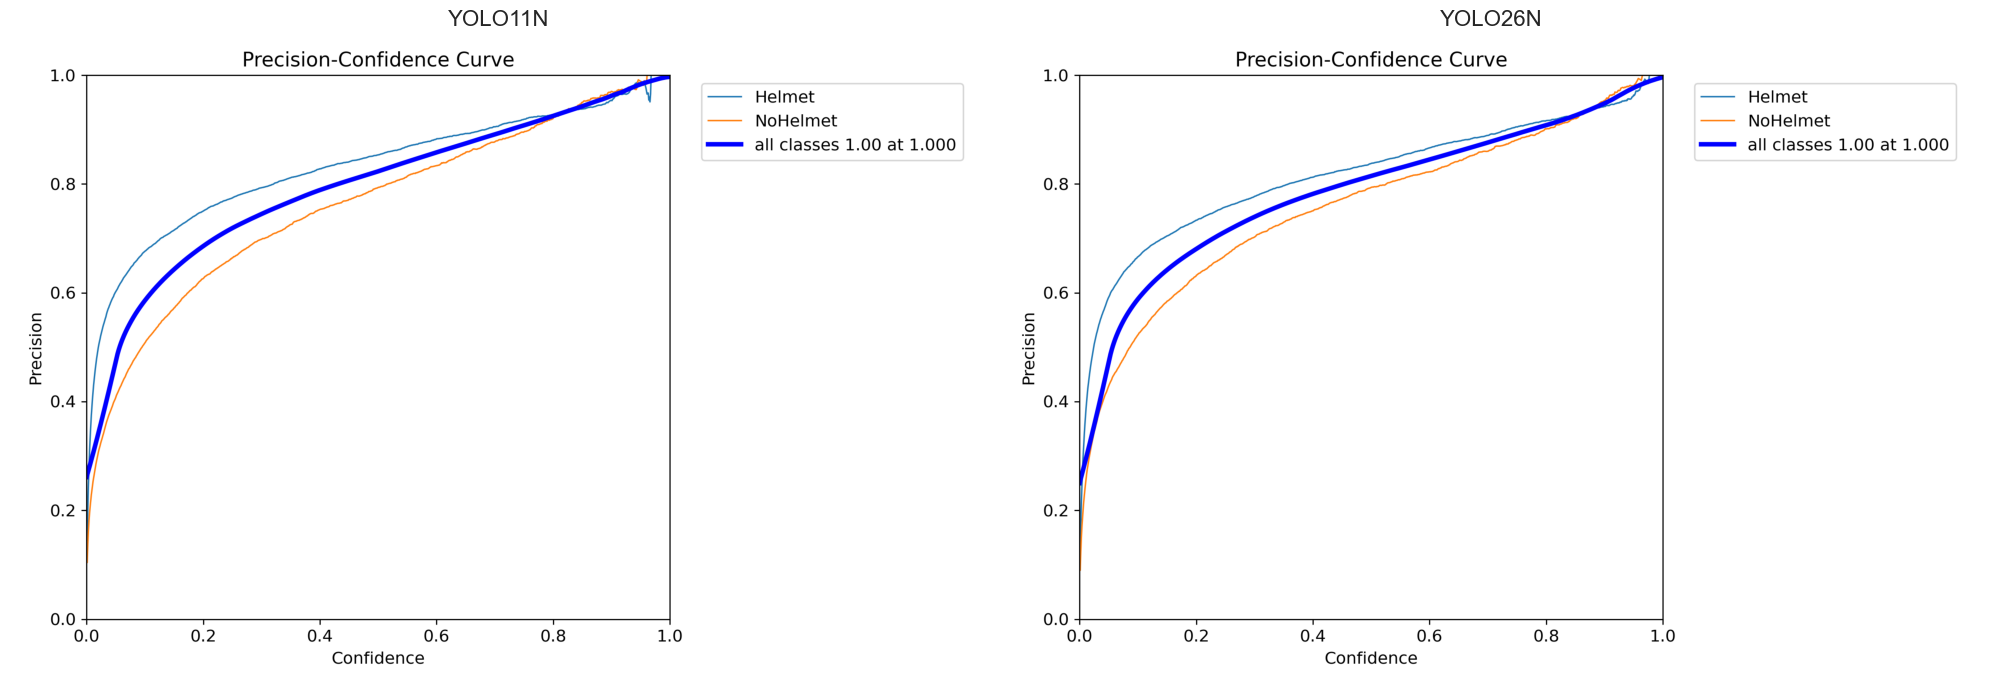

In [6]:
# F1 and Precision Confidence curve
plot_types = ["BoxF1_curve.png", "BoxP_curve.png"] 

for p_type in plot_types:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    for i, m_name in enumerate(models):
        img_path = os.path.join(OUTPUT_DIR, m_name, p_type)
        
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            axes[i].set_title(f"{m_name.upper()}", fontsize=16, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f"{p_type} not found for {m_name}", ha='center', va='center')
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{p_type.split(".")[0]}_comparison.png")
    plt.show()